In [ ]:
# BASIC STEPS

!pip install transformers
!pip install opencv-python
!pip install tensorboard
!pip install timm

import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
from torchvision import models, transforms
import time
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTFeatureExtractor
import numpy as np
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from timm import create_model
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm





from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
METADATA_PATH = "/content/drive/MyDrive/THESIS/Dataset/kaggle/ISIC_2020_Train_Metadata.csv"

# Load the metadata
df = pd.read_csv(METADATA_PATH)

# Count melanoma samples (target == 1)
num_melanoma = df[df['target'] == 1].shape[0]
num_mb = df[df['target'] == 0].shape[0]

print(f"✅ You have {num_melanoma} melanoma images in your ISIC 2020 training dataset.")
print(f"✅ You have {num_mb} benign images in your ISIC 2020 training dataset.")


✅ You have 584 melanoma images in your ISIC 2020 training dataset.
✅ You have 32542 benign images in your ISIC 2020 training dataset.


In [ ]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# Paths
DATASET_DIR = "/content/drive/MyDrive/THESIS/Dataset/kaggle/train"
METADATA_PATH = "/content/drive/MyDrive/THESIS/Dataset/kaggle/ISIC_2020_Train_Metadata.csv"

# Target folders
BENIGN_DIR = os.path.join(DATASET_DIR, "Benign")
MELANOMA_DIR = os.path.join(DATASET_DIR, "Melanoma")

# Ensure folders exist
os.makedirs(BENIGN_DIR, exist_ok=True)
os.makedirs(MELANOMA_DIR, exist_ok=True)

# Load metadata
df = pd.read_csv(METADATA_PATH)

# Move images
for _, row in tqdm(df.iterrows(), total=len(df), desc="Moving images"):
    img_name = row["image_name"] + ".jpg"
    src_path = os.path.join(DATASET_DIR, img_name)

    # Check image exists
    if not os.path.isfile(src_path):
        print(f"⚠️ Missing file: {img_name}")
        continue

    # Determine class
    target = row["target"]
    dest_dir = MELANOMA_DIR if target == 1 else BENIGN_DIR
    dest_path = os.path.join(dest_dir, img_name)

    # Move file
    shutil.move(src_path, dest_path)

print("\n✅ All melanoma and benign images moved into their respective folders.")


Moving images: 100%|██████████| 33126/33126 [01:25<00:00, 389.25it/s]


✅ All melanoma and benign images moved into their respective folders.


In [ ]:
import os

# Paths to your folders
benign_folder = "/content/drive/MyDrive/THESIS/Dataset/kaggle/train/Benign"
melanoma_folder = "/content/drive/MyDrive/THESIS/Dataset/kaggle/train/Melanoma"
train_folder = "/content/drive/MyDrive/THESIS/Dataset/kaggle/train"
# Get list of all .jpg files directly in /train/ (exclude subfolders)
unmoved_images = [
    f for f in os.listdir(train_folder)
    if f.lower().endswith(".jpg") and os.path.isfile(os.path.join(train_folder, f))
]

def count_images(folder):
    # Count files with typical image extensions
    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
    return len([f for f in os.listdir(folder) if f.lower().endswith(valid_extensions)])

benign_count = count_images(benign_folder)
melanoma_count = count_images(melanoma_folder)

print(f"Number of images in Benign folder: {benign_count}")
print(f"Number of images in Melanoma folder: {melanoma_count}")
# Output result
print(f"Number of images still in /train/ (not in Benign or Melanoma): {len(unmoved_images)}")


Number of images in Benign folder: 32542
Number of images in Melanoma folder: 12264
Number of images still in /train/ (not in Benign or Melanoma): 8


In [ ]:
import os
import pandas as pd
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# ---- CONFIG ----
N_AUG = 20
MELANOMA_FOLDER = "/content/drive/MyDrive/THESIS/Dataset/kaggle/train/Melanoma"
METADATA_PATH = "/content/drive/MyDrive/THESIS/Dataset/kaggle/ISIC_2020_Train_Metadata.csv"

# Load metadata
df = pd.read_csv(METADATA_PATH)
melanoma_df = df[df["target"] == 1].copy()

# Augmentation pipeline
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.ToTensor()
])

# Track new metadata
new_metadata_rows = []

for _, row in tqdm(melanoma_df.iterrows(), total=len(melanoma_df), desc="Resuming augmentation"):
    img_name = row["image_name"]
    img_path = os.path.join(MELANOMA_FOLDER, img_name + ".jpg")

    if not os.path.exists(img_path):
        continue

    try:
        original_img = Image.open(img_path).convert("RGB")
    except Exception:
        continue

    for i in range(N_AUG):
        new_img_name = f"{img_name}_aug{i+1}"
        new_img_path = os.path.join(MELANOMA_FOLDER, new_img_name + ".jpg")

        # Skip if already augmented
        if os.path.exists(new_img_path):
            continue

        aug_tensor = augmentation(original_img)
        aug_img = transforms.ToPILImage()(aug_tensor)
        aug_img.save(new_img_path)

        # Add to metadata
        new_row = row.copy()
        new_row["image_name"] = new_img_name
        new_metadata_rows.append(new_row)

# Append to CSV
if new_metadata_rows:
    updated_df = pd.DataFrame(new_metadata_rows)
    final_df = pd.concat([df, updated_df], ignore_index=True)
    final_df.to_csv(METADATA_PATH, index=False)
    print(f"\n✅ Resumed and completed: {len(new_metadata_rows)} new images saved.")
else:
    print("\n✅ All augmentations were already completed previously. Nothing new added.")


Resuming augmentation: 100%|██████████| 584/584 [44:46<00:00,  4.60s/it]



✅ Resumed and completed: 7250 new images saved.


Train Metadata Loaded: (40376, 9)
Test Metadata Loaded: (10982, 5)
Filtered Train Metadata Size: 40376
Filtered Test Metadata Size: 10982
Train Metadata After Removing Rare Classes: 40374
Label Mapping:
{'lentigo NOS': 0, 'lichenoid keratosis': 1, 'melanoma': 2, 'nevus': 3, 'seborrheic keratosis': 4, 'solar lentigo': 5, 'unknown': 6}

Visualizing sample training images...


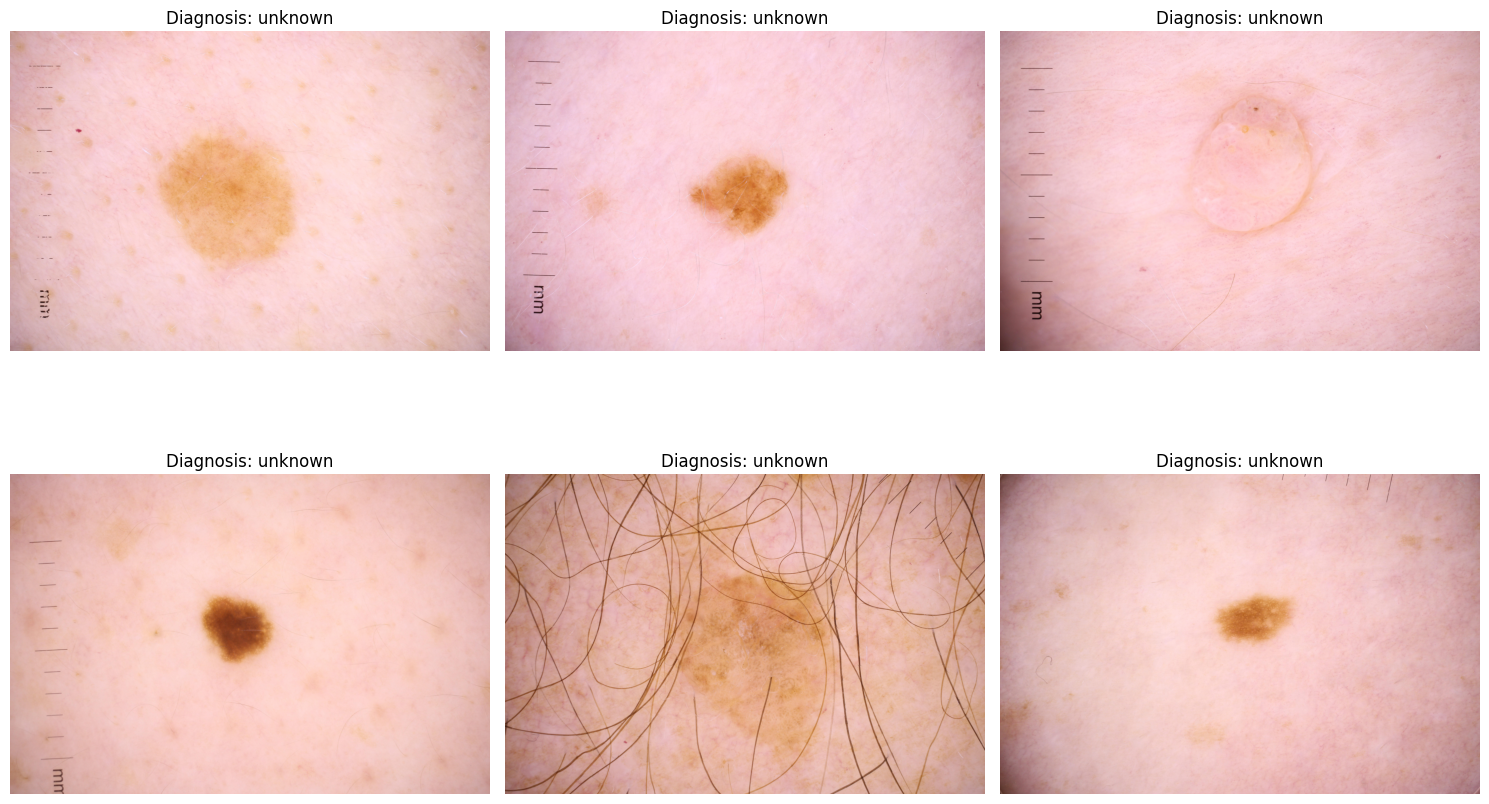

Training samples: 32299, Validation samples: 8075
DataLoaders created successfully.
Sample Images Shape: torch.Size([128, 3, 224, 224])
Sample Labels Shape: torch.Size([128])


In [ ]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

# UPDATED PATHS
DATASET_PATH = "/content/drive/MyDrive/THESIS/Dataset/kaggle"
TRAIN_IMAGES_PATH = os.path.join(DATASET_PATH, "train")
TRAIN_BENIGN_PATH = os.path.join(TRAIN_IMAGES_PATH, "Benign")
TRAIN_MELANOMA_PATH = os.path.join(TRAIN_IMAGES_PATH, "Melanoma")
TEST_IMAGES_PATH = os.path.join(DATASET_PATH, "test")

TRAIN_METADATA_PATH = os.path.join(DATASET_PATH, "ISIC_2020_Train_Metadata.csv")
TEST_METADATA_PATH = os.path.join(DATASET_PATH, "ISIC_2020_Test_Metadata.csv")

# VERIFY PATHS
for path in [TRAIN_METADATA_PATH, TEST_METADATA_PATH, TRAIN_BENIGN_PATH, TRAIN_MELANOMA_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Path does not exist: {path}")

# LOAD METADATA
train_metadata = pd.read_csv(TRAIN_METADATA_PATH)
test_metadata = pd.read_csv(TEST_METADATA_PATH)

print(f"Train Metadata Loaded: {train_metadata.shape}")
print(f"Test Metadata Loaded: {test_metadata.shape}")

# ADD EXTENSIONS
train_metadata['image_name_with_ext'] = train_metadata['image_name'].astype(str) + '.jpg'
test_metadata['image_name_with_ext'] = test_metadata['image'].astype(str) + '.jpg'

# GET IMAGE FILES FROM BOTH SUBFOLDERS
train_image_files = set(os.listdir(TRAIN_BENIGN_PATH)) | set(os.listdir(TRAIN_MELANOMA_PATH))
test_image_files = set(os.listdir(TEST_IMAGES_PATH))

# FILTER METADATA BASED ON AVAILABLE FILES
filtered_train_metadata = train_metadata[train_metadata['image_name_with_ext'].isin(train_image_files)].copy()
filtered_test_metadata = test_metadata[test_metadata['image_name_with_ext'].isin(test_image_files)].copy()

print(f"Filtered Train Metadata Size: {len(filtered_train_metadata)}")
print(f"Filtered Test Metadata Size: {len(filtered_test_metadata)}")

# REMOVE CLASSES WITH < 2 SAMPLES
train_class_counts = filtered_train_metadata['diagnosis'].value_counts()
valid_classes = train_class_counts[train_class_counts > 1].index.tolist()

filtered_train_metadata = filtered_train_metadata[filtered_train_metadata['diagnosis'].isin(valid_classes)].copy()
print(f"Train Metadata After Removing Rare Classes: {len(filtered_train_metadata)}")

# ENCODE LABELS
label_mapping = {label: idx for idx, label in enumerate(sorted(filtered_train_metadata['diagnosis'].unique()))}
filtered_train_metadata['label'] = filtered_train_metadata['diagnosis'].map(label_mapping)

print(f"Label Mapping:\n{label_mapping}")

# VISUALIZE SAMPLES
def visualize_samples(metadata, num_samples=6):
    if metadata.empty:
        print("No valid samples to visualize.")
        return

    samples = metadata.sample(n=min(num_samples, len(metadata)))
    plt.figure(figsize=(15, 10))

    for idx, (_, row) in enumerate(samples.iterrows()):
        subfolder = "Melanoma" if row["benign_malignant"] == "malignant" else "Benign"
        img_path = os.path.join(TRAIN_IMAGES_PATH, subfolder, row['image_name_with_ext'])

        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Image not found or corrupted: {img_path}")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, idx + 1)
        plt.imshow(image)
        plt.title(f"Diagnosis: {row['diagnosis']}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizing sample training images...")
visualize_samples(filtered_train_metadata)

# SPLIT TRAIN-VALIDATION
if filtered_train_metadata.empty:
    raise ValueError("Filtered training metadata is empty. Cannot split train/val.")

train_df, val_df = train_test_split(
    filtered_train_metadata,
    test_size=0.2,
    stratify=filtered_train_metadata['label'],
    random_state=42
)

print(f"Training samples: {len(train_df)}, Validation samples: {len(val_df)}")

# DATASET CLASS
class ISICDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        label_mapping = {"Benign": 0, "Melanoma": 1}

        for label_name, label_idx in label_mapping.items():
            class_dir = os.path.join(base_dir, label_name)
            if not os.path.exists(class_dir):
                continue
            for img_name in os.listdir(class_dir):
                if img_name.endswith(".jpg") or img_name.endswith(".png"):
                    self.image_paths.append(os.path.join(class_dir, img_name))
                    self.labels.append(label_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found or unreadable at: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        return image, label


# TRANSFORMS
data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# DATA LOADERS
train_dataset = ISICDataset(train_df, TRAIN_IMAGES_PATH, transform=data_transforms)
val_dataset = ISICDataset(val_df, TRAIN_IMAGES_PATH, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=12, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=12, pin_memory=True)

print("DataLoaders created successfully.")

# TEST THE LOADER
sample_images, sample_labels = next(iter(train_loader))
print(f"Sample Images Shape: {sample_images.shape}")
print(f"Sample Labels Shape: {sample_labels.shape}")


In [ ]:
# LETS GO BERSERK!
# with Ballanced Dataset 2nd try
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone va Extract features from the penultimate layer
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # It removes classifier (keeps features)

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers to prevent them from training
        for param in self.resnet_feat.parameters():
            param.requires_grad = False

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False

        for param in self.densenet_feat.parameters():
            param.requires_grad = False

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate the total input size dynamically for the fully connected layer
        fc_input_size = 0

        # Function to calculate the feature size from a model
        def calculate_fc_input_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                # If the model output is a list, get the first tensor
                if isinstance(output, list):
                    output = output[0]
                output = self.global_pool(output)
                output = torch.flatten(output, 1)
                return output.shape[1]

        # Create a dummy input to calculate the feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)  # Create a dummy input

        # Calculate the input size for each backbone
        fc_input_size += calculate_fc_input_size(self.resnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.efficientnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.densenet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.swin_feat, dummy_input)

        # Calculate the total input size for the fully connected layer
        fc_input_size = 2048 + 1792 + 1920 + 7

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from ResNet
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        # Extract features from EfficientNet
        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        # Extract features from DenseNet
        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        # Extract features from Swin Transformer
        swin_feats = self.swin_feat(x)[-1]        # Get last feature map
        swin_out = self.global_pool(swin_feats)   # (B, C, 1, 1)
        swin_out = torch.flatten(swin_out, 1)     # Now (B, C)

        # Concatenate all features
        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        # Classification head
        out = self.fc(combined_features)
        return out



# Initialize the Berserker model
NUM_CLASSES = 7
model = Berserker(num_classes=NUM_CLASSES)

# Define the optimizer
optimizer = optim.AdamW(
    params=[param for param in model.parameters() if param.requires_grad],
    lr=1e-4,
    weight_decay=1e-4
)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Check if there's a saved checkpoint
checkpoint_path = "/content/drive/MyDrive/2nd_best_model.pth"
start_epoch = 0

if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Resuming from epoch {start_epoch}")

# Training loop with checkpoint saving
def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, checkpoint_path="2nd_best_model.pth", patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(start_epoch, num_epochs):  # Starts from the last epoch
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        # Training phase
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()  # Reset gradients

            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass

            optimizer.step()  # Update weights

            # Track statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Compute training accuracy
        train_accuracy = 100 * train_correct / train_total

        # Validation phase
        model.eval()  # Set model to evaluation mode (turn off dropout, batch norm, etc.)
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # Disable gradient tracking
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Track statistics
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Compute validation accuracy
        val_accuracy = 100 * val_correct / val_total

        # Print epoch statistics
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%")
        print(f"Epoch [{epoch+1}/{num_epochs}], Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Saves the model checkpoint if it has the best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            print(f"Validation loss decreased, saving the model...")

            # Save checkpoint
            torch.save({
                'epoch': epoch + 1,  # Save the current epoch
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, checkpoint_path)
            print(f"Checkpoint saved to {checkpoint_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping after {epoch+1} epochs.")
                break

# Call the training function with my model, data loaders, optimizer, and loss function
train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, checkpoint_path=checkpoint_path)


[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 1000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
[INFO] Loaded 2000 images so far...
Epoch [1/10], Train Loss: 0.3074, Train Accuracy: 92.11%
Epoch [1/10], Val Loss: 0.1917, Val Accuracy: 95.52%
Validation loss decreased,

In [ ]:
# LETS GO BERSERK!
# with Imballanced Dataset
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone va Extract features from the penultimate layer
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # It removes classifier (keeps features)

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers to prevent them from training
        for param in self.resnet_feat.parameters():
            param.requires_grad = False

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False

        for param in self.densenet_feat.parameters():
            param.requires_grad = False

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate the total input size dynamically for the fully connected layer
        fc_input_size = 0

        # Function to calculate the feature size from a model
        def calculate_fc_input_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                # If the model output is a list, get the first tensor
                if isinstance(output, list):
                    output = output[0]
                output = self.global_pool(output)
                output = torch.flatten(output, 1)
                return output.shape[1]

        # Create a dummy input to calculate the feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)  # Create a dummy input

        # Calculate the input size for each backbone
        fc_input_size += calculate_fc_input_size(self.resnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.efficientnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.densenet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.swin_feat, dummy_input)

        # Calculate the total input size for the fully connected layer
        fc_input_size = 2048 + 1792 + 1920 + 7

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from each backbone
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        # Extract features from Swin Transformer
        swin_feats = self.swin_feat(x)[-1]  # Get the last feature map (tensor)
        swin_out = self.global_pool(swin_feats)

        # Concatenate all the extracted features
        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        # Final classification
        out = self.fc(combined_features)
        return out


# Initialize the Berserker model
NUM_CLASSES = 7
model = Berserker(num_classes=NUM_CLASSES)

# Define the optimizer
optimizer = optim.AdamW(
    params=[param for param in model.parameters() if param.requires_grad],
    lr=1e-4,
    weight_decay=1e-4
)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Check if there's a saved checkpoint
checkpoint_path = "/content/drive/MyDrive/best_model.pth"
start_epoch = 0

if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Resuming from epoch {start_epoch}")

# Training loop with checkpoint saving
def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, checkpoint_path="best_model.pth", patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(start_epoch, num_epochs):  # Starts from the last epoch
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        # Training phase
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()  # Reset gradients

            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass

            optimizer.step()  # Update weights

            # Track statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Compute training accuracy
        train_accuracy = 100 * train_correct / train_total

        # Validation phase
        model.eval()  # Set model to evaluation mode (turn off dropout, batch norm, etc.)
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # Disable gradient tracking
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Track statistics
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Compute validation accuracy
        val_accuracy = 100 * val_correct / val_total

        # Print epoch statistics
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%")
        print(f"Epoch [{epoch+1}/{num_epochs}], Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Saves the model checkpoint if it has the best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            print(f"Validation loss decreased, saving the model...")

            # Save checkpoint
            torch.save({
                'epoch': epoch + 1,  # Save the current epoch
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, checkpoint_path)
            print(f"Checkpoint saved to {checkpoint_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping after {epoch+1} epochs.")
                break

# Call the training function with my model, data loaders, optimizer, and loss function
train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, checkpoint_path=checkpoint_path)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 452MB/s]
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 457MB/s]


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading checkpoint from /content/drive/MyDrive/best_model.pth
Resuming from epoch 7
Epoch [8/10], Train Loss: 0.1702, Train Accuracy: 94.84%
Epoch [8/10], Val Loss: 0.1899, Val Accuracy: 94.67%
Validation loss decreased, saving the model...
Checkpoint saved to /content/drive/MyDrive/best_model.pth
Epoch [9/10], Train Loss: 0.1652, Train Accuracy: 94.99%
Epoch [9/10], Val Loss: 0.1921, Val Accuracy: 94.79%
Epoch [10/10], Train Loss: 0.1598, Train Accuracy: 95.05%
Epoch [10/10], Val Loss: 0.2072, Val Accuracy: 94.64%


In [ ]:
# Ballancing ISIC 2019
import os
import shutil
import pandas as pd

# Input paths
DATASET_DIR = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Input"
METADATA_PATH = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_GroundTruth.csv"

# Output folders
melanoma_dir = os.path.join(DATASET_DIR, "Melanoma")
other_dir = os.path.join(DATASET_DIR, "Other")
os.makedirs(melanoma_dir, exist_ok=True)
os.makedirs(other_dir, exist_ok=True)

# Load metadata
df = pd.read_csv(METADATA_PATH)

# Process each image
mel_count, other_count = 0, 0
for _, row in df.iterrows():
    image_id = row['image']
    mel_label = row['MEL']

    src_path = os.path.join(DATASET_DIR, image_id + ".jpg")
    if not os.path.exists(src_path):
        print(f"[WARNING] Missing image: {src_path}")
        continue

    # Choose destination folder
    if mel_label == 1:
        target_dir = melanoma_dir
        mel_count += 1
    else:
        target_dir = other_dir
        other_count += 1

    dst_path = os.path.join(target_dir, image_id + ".jpg")
    shutil.move(src_path, dst_path)

print(f"✅ Completed.")
print(f"Moved {mel_count} Melanoma images.")
print(f"Moved {other_count} Other images.")



✅ Completed.
Moved 1327 Melanoma images.
Moved 6911 Other images.


In [ ]:
# Checking 2019 dataset after spliting

import os

# Paths to your folders
other_folder = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Input/Other"
melanoma_folder = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Input/Melanoma"
test_folder = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Input"
# Get list of all .jpg files directly in /test/ (exclude subfolders)
unmoved_images = [
    f for f in os.listdir(test_folder)
    if f.lower().endswith(".jpg") and os.path.isfile(os.path.join(test_folder, f))
]

def count_images(folder):
    # Count files with typical image extensions
    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
    return len([f for f in os.listdir(folder) if f.lower().endswith(valid_extensions)])

other_count = count_images(other_folder)
melanoma_count = count_images(melanoma_folder)

print(f"Number of images in Other folder: {other_count}")
print(f"Number of images in Melanoma folder: {melanoma_count}")
# Output result
print(f"Number of images still in /train/ (not in Benign or Melanoma): {len(unmoved_images)}")




Number of images in Other folder: 5528
Number of images in Melanoma folder: 1052
Number of images still in /train/ (not in Benign or Melanoma): 1658


In [ ]:
import os
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from timm import create_model
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# --- Model definition ---

class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])

        # DenseNet201 Backbone
        densenet = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone (features_only=True returns list of feature maps)
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone parameters
        for param in self.resnet_feat.parameters():
            param.requires_grad = False
        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False
        for param in self.densenet_feat.parameters():
            param.requires_grad = False
        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate input feature size dynamically using a dummy input
        def calc_feat_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                if isinstance(output, list):
                    output = output[-1]  # Use last feature map for swin transformer
                pooled = self.global_pool(output)
                flattened = torch.flatten(pooled, 1)
                return flattened.shape[1]

        dummy_input = torch.randn(1, 3, 224, 224)

        resnet_size = calc_feat_size(self.resnet_feat, dummy_input)
        efficientnet_size = calc_feat_size(self.efficientnet_feat, dummy_input)
        densenet_size = calc_feat_size(self.densenet_feat, dummy_input)
        swin_size = calc_feat_size(self.swin_feat, dummy_input)

        fc_input_size = resnet_size + efficientnet_size + densenet_size + swin_size

        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        swin_feats = self.swin_feat(x)[-1]  # last feature map
        swin_out = self.global_pool(swin_feats)
        swin_out = torch.flatten(swin_out, 1)

        combined = torch.cat([resnet_out, efficientnet_out, densenet_out, swin_out], dim=1)

        out = self.fc(combined)
        return out
# --- Dataset ---

class ISICTestDataset(Dataset):
    def __init__(self, root_dir, metadata_csv, transform=None):
        self.transform = transform
        self.samples = []
        self.image_names = []

        metadata = pd.read_csv(metadata_csv)
        filtered_meta = metadata[(metadata['SCC'] == 0) & (metadata['UNK'] == 0)]
        allowed_images = set(filtered_meta['image'].values)

        for dirpath, _, filenames in os.walk(root_dir):
            for fname in filenames:
                if fname.lower().endswith(".jpg"):
                    image_name = os.path.splitext(fname)[0]
                    if image_name in allowed_images:
                        full_path = os.path.join(dirpath, fname)
                        if os.path.isfile(full_path):
                            self.samples.append(full_path)
                            self.image_names.append(image_name)


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image = cv2.imread(self.samples[idx])
        if image is None:
            raise FileNotFoundError(f"Could not read image: {self.samples[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)
        return image, self.image_names[idx]

# --- Setup ---

TEST_IMAGES_PATH = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Input"
METADATA_PATH = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_GroundTruth.csv"

data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

NUM_CLASSES = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Berserker(NUM_CLASSES).to(device)

checkpoint = torch.load("/content/drive/MyDrive/2nd_best_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_dataset = ISICTestDataset(TEST_IMAGES_PATH, METADATA_PATH, transform=data_transforms)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=12, pin_memory=True)

# --- Inference ---

predictions = []
image_names = []

with torch.no_grad():
    for images, names in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        # Predict the class with the highest probability
        pred_classes = torch.argmax(probs, dim=1)

        # Binary classification: 1 if predicted class is melanoma (index 0), else 0
        binary_preds = (pred_classes == 0).long()

        predictions.extend(binary_preds.cpu().numpy())
        image_names.extend(names)

# --- Save predictions ---

results = pd.DataFrame({'image': image_names, 'predicted_label': predictions})
results.to_csv("/content/drive/MyDrive/2nd_test_predictions.csv", index=False)

# --- Evaluation ---

ground_truth = pd.read_csv(METADATA_PATH)
ground_truth['binary_label'] = ground_truth['MEL']

merged = pd.merge(results, ground_truth[['image', 'binary_label']], on='image')

y_true = merged['binary_label'].values
y_pred = merged['predicted_label'].values

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
report = classification_report(y_true, y_pred, target_names=['Non-Melanoma', 'Melanoma'], zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", report)



Accuracy: 0.7798
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

Classification Report:
               precision    recall  f1-score   support

Non-Melanoma       0.78      1.00      0.88      4699
    Melanoma       0.00      0.00      0.00      1327

    accuracy                           0.78      6026
   macro avg       0.39      0.50      0.44      6026
weighted avg       0.61      0.78      0.68      6026



In [ ]:
# Testing
# Trained on Imballanced Dataset
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])  # Removes AvgPool & FC

        # EfficientNetB4 Backbone - Extract features from the penultimate layer
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # Removes classifier (keep features)

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers to prevent them from training
        for param in self.resnet_feat.parameters():
            param.requires_grad = False

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False

        for param in self.densenet_feat.parameters():
            param.requires_grad = False

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate the total input size dynamically for the fully connected layer
        fc_input_size = 0

        # Function to calculate the feature size from a model
        def calculate_fc_input_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                # If the model output is a list, get the first tensor
                if isinstance(output, list):
                    output = output[0]
                output = self.global_pool(output)
                output = torch.flatten(output, 1)
                return output.shape[1]

        # Create a dummy input to calculate the feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)  # Create a dummy input

        # Calculate the input size for each backbone
        fc_input_size += calculate_fc_input_size(self.resnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.efficientnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.densenet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.swin_feat, dummy_input)

        # Calculate the total input size for the fully connected layer
        fc_input_size = 2048 + 1792 + 1920 + 7  # Corrected fc_input_size based on feature sizes

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),  # Use the calculated fc_input_size
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from each backbone
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        # Extract features from Swin Transformer
        swin_feats = self.swin_feat(x)[-1]  # Get the last feature map (tensor)
        swin_out = self.global_pool(swin_feats)  # Apply global pooling
        swin_out = torch.flatten(swin_out, 1)

        # Concatenate all the extracted features
        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        # Final classification
        out = self.fc(combined_features)
        return out


# Initialize the Berserker model
NUM_CLASSES = 7
model = Berserker(num_classes=NUM_CLASSES)

# Define the optimizer
optimizer = optim.AdamW(
    params=[param for param in model.parameters() if param.requires_grad],
    lr=1e-4,
    weight_decay=1e-4
)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# After training is complete, I need to proceed with testing the model
# Test dataset
class ISICTestDataset(Dataset):
    def __init__(self, metadata, image_dir, transform=None):
        self.metadata = metadata.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image'] + '.jpg')  # Adjust column if needed

        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found or unreadable at: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        return image

# Test DataLoader
test_dataset = ISICTestDataset(test_metadata, TEST_IMAGES_PATH, transform=data_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Ensure the model and inputs are on the same device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model.to(device)

# Inference
model.eval()  # Set the model to evaluation mode

predictions = []
image_names = []

with torch.no_grad():  # Turn off gradient computation
    for images in test_loader:
        images = images.to(device)  # Moves images to device

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Store the predictions and image filenames
        predictions.extend(predicted.cpu().numpy())
        image_names.extend(test_metadata['image'].iloc[:len(predicted)].tolist())

# Save the predictions to a CSV
results = pd.DataFrame({'image': image_names, 'predicted_label': predictions})
results.to_csv("/content/drive/MyDrive/test_predictions.csv", index=False)

print("Predictions saved successfully.")


Predictions saved successfully.


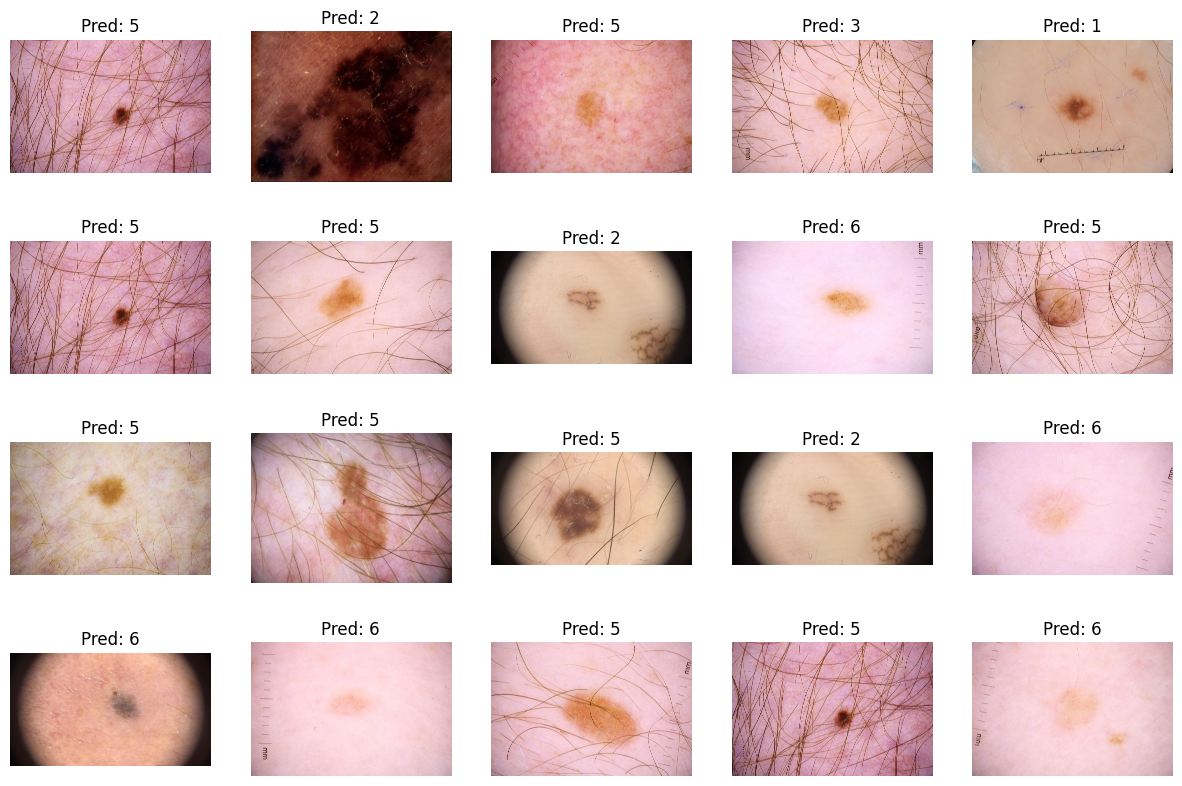

In [ ]:

import random



# Show random images with their predicted labels
sample_images = random.sample(predictions_df['image'].tolist(), 20)  # Pick 5 random images

plt.figure(figsize=(15, 10))
for idx, image_name in enumerate(sample_images):
    # Ensure the image name includes the correct extension, e.g., '.jpg'
    image_path = os.path.join(TEST_IMAGES_PATH, image_name + '.jpg')  # Add file extension

    # Check if image exists
    if os.path.exists(image_path):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for correct display

        # Find the predicted label for the image
        predicted_label = predictions_df[predictions_df['image'] == image_name]['predicted_label'].values[0]

        # Display the image with predicted label
        plt.subplot(4, 5, idx + 1)  # Arrange images in a single row
        plt.imshow(img)
        plt.title(f"Pred: {predicted_label}")
        plt.axis('off')
    else:
        print(f"Image not found: {image_path}")

plt.show()


In [ ]:
# Metrics
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])  # Removes AvgPool & FC

        # EfficientNetB4 Backbone - Extract features from the penultimate layer
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # Removes classifier (keep features)

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers to prevent them from training
        for param in self.resnet_feat.parameters():
            param.requires_grad = False

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False

        for param in self.densenet_feat.parameters():
            param.requires_grad = False

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate the total input size dynamically for the fully connected layer
        fc_input_size = 0

        # Function to calculate the feature size from a model
        def calculate_fc_input_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                # If the model output is a list, get the first tensor
                if isinstance(output, list):
                    output = output[0]
                output = self.global_pool(output)
                output = torch.flatten(output, 1)
                return output.shape[1]

        # Create a dummy input to calculate the feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)  # Create a dummy input

        # Calculate the input size for each backbone
        fc_input_size += calculate_fc_input_size(self.resnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.efficientnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.densenet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.swin_feat, dummy_input)

        # Calculate the total input size for the fully connected layer
        fc_input_size = 2048 + 1792 + 1920 + 7  # Corrected fc_input_size based on feature sizes

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),  # Use the calculated fc_input_size
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from each backbone
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        # Extract features from Swin Transformer
        swin_feats = self.swin_feat(x)[-1]  # Get the last feature map (tensor)
        swin_out = self.global_pool(swin_feats)  # Apply global pooling
        swin_out = torch.flatten(swin_out, 1)

        # Concatenate all the extracted features
        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        # Final classification
        out = self.fc(combined_features)
        return out



def calculate_all_metrics(y_true, y_pred, y_probs):
    # Confusion Matrix: [TN, FP, FN, TP]
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Sensitivity (Recall)
    sensitivity = recall_score(y_true, y_pred)

    # Specificity
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    # Precision
    precision = precision_score(y_true, y_pred)

    # F1 Score
    f1 = f1_score(y_true, y_pred)

    # AUC - ROC (Area Under the Curve)
    auc = roc_auc_score(y_true, y_probs)

    return {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1_score': f1,
        'roc_auc': auc
    }

# Assuming your model and test set are ready
model.eval()  # Set model to evaluation mode
y_true = []  # Store true labels
y_pred = []  # Store predicted labels
y_probs = []  # Store predicted probabilities for ROC-AUC

with torch.no_grad():
    for inputs, labels in test_loader:  # Use your test data loader
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        # Store the true labels and predictions
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        # Store the predicted probabilities (needed for AUC)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        y_probs.extend(probs[:, 1].cpu().numpy())  # Probabilities for positive class

# Calculate all metrics
metrics = calculate_all_metrics(y_true, y_pred, y_probs)

# Print metrics
for metric, value in metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")


NameError: name 'model' is not defined

100%|██████████| 8238/8238 [5:05:41<00:00,  2.23s/it]



✅ Evaluation Results:
Accuracy       : 0.5749
Precision      : 0.2226
Recall         : 0.6579
F1 Score       : 0.3327
AUC-ROC        : 0.6703

Confusion Matrix:
[[3863 3048]
 [ 454  873]]

Classification Report:
              precision    recall  f1-score   support

Non-Melanoma       0.89      0.56      0.69      6911
    Melanoma       0.22      0.66      0.33      1327

    accuracy                           0.57      8238
   macro avg       0.56      0.61      0.51      8238
weighted avg       0.79      0.57      0.63      8238


✅ Evaluation results saved to: /content/drive/MyDrive/THESIS/Berserker_ISIC2019_Test_Evaluation.csv


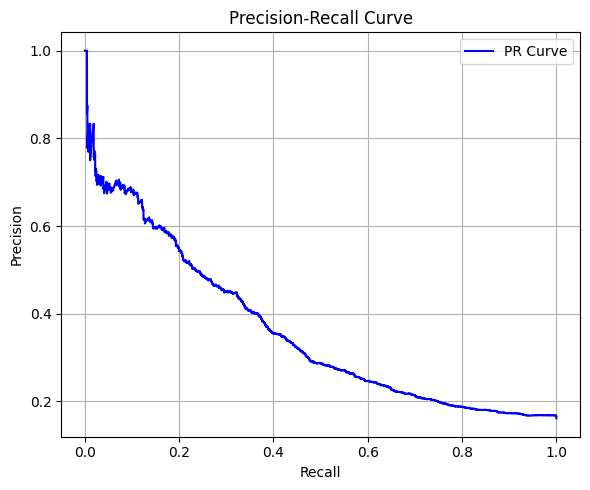

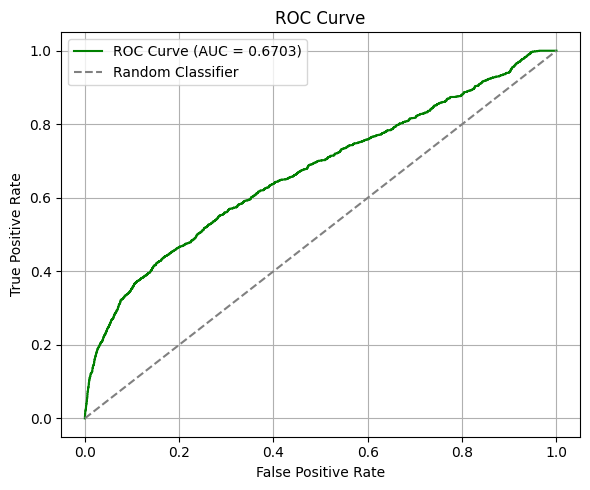

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from timm import create_model

# ----- BERSERKER MODEL -----
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers
        for param in self.resnet_feat.parameters():
            param.requires_grad = False
        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False
        for param in self.densenet_feat.parameters():
            param.requires_grad = False
        for param in self.swin_feat.parameters():
            param.requires_grad = False

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fixed input size based on known output shapes
        fc_input_size = 2048 + 1792 + 1920 + 7

        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        resnet_out = self.global_pool(self.resnet_feat(x))
        resnet_out = torch.flatten(resnet_out, 1)

        efficientnet_out = self.global_pool(self.efficientnet_feat(x))
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        densenet_out = self.global_pool(self.densenet_feat(x))
        densenet_out = torch.flatten(densenet_out, 1)

        swin_feats = self.swin_feat(x)[-1]
        swin_out = self.global_pool(swin_feats)
        swin_out = torch.flatten(swin_out, 1)

        combined = torch.cat([resnet_out, efficientnet_out, densenet_out, swin_out], dim=1)
        return self.fc(combined)

# ----- CONFIG -----
test_image_dir = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Input'
ground_truth_csv = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_GroundTruth.csv'
model_weights_path = '/content/drive/MyDrive/best_model.pth'
output_csv_path = '/content/drive/MyDrive/THESIS/Berserker_ISIC2019_Test_Evaluation.csv'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ----- LOAD MODEL -----
MELANOMA_CLASS_INDEX = 2  # <- VERIFY THIS BASED ON YOUR training label mapping
model = Berserker(num_classes=7).to(device)
checkpoint = torch.load(model_weights_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ----- GROUND TRUTH -----
gt_df = pd.read_csv(ground_truth_csv)
gt_df['image'] = gt_df['image'].astype(str)
gt_df['true_label'] = gt_df['MEL'].astype(int)

# ----- PREDICTION LOOP -----
predictions = []
true_labels = []
predicted_probs = []
processed_images = []

# 🔽 NEW THRESHOLD: TUNE THIS FOR RECALL
threshold = 0.1

for _, row in tqdm(gt_df.iterrows(), total=len(gt_df)):
    image_id = row['image']
    true_binary_label = row['true_label']

    img_path_jpg = os.path.join(test_image_dir, image_id + '.jpg')
    img_path_png = os.path.join(test_image_dir, image_id + '.png')

    img_path = img_path_jpg if os.path.exists(img_path_jpg) else (
        img_path_png if os.path.exists(img_path_png) else None
    )

    if img_path is None:
        print(f"❌ Missing image: {image_id}. Skipping.")
        continue

    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"⚠️ Error reading image {image_id}: {e}. Skipping.")
        continue

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        probs_all_classes = torch.nn.functional.softmax(output, dim=1)

        melanoma_prob = probs_all_classes[:, MELANOMA_CLASS_INDEX].item()
        predicted_probs.append(melanoma_prob)

        # 🔽 APPLY NEW THRESHOLD
        binary_pred = 1 if melanoma_prob >= threshold else 0

        predictions.append(binary_pred)
        true_labels.append(true_binary_label)
        processed_images.append(image_id)

# ----- METRICS -----
if not true_labels:
    print("❌ No predictions made. Check image paths.")
else:
    true_labels_np = np.array(true_labels)
    predictions_np = np.array(predictions)
    predicted_probs_np = np.array(predicted_probs)

    acc = accuracy_score(true_labels_np, predictions_np)
    prec = precision_score(true_labels_np, predictions_np, zero_division=0)
    rec = recall_score(true_labels_np, predictions_np, zero_division=0)
    f1 = f1_score(true_labels_np, predictions_np, zero_division=0)

    print("\n✅ Evaluation Results:")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall         : {rec:.4f}")
    print(f"F1 Score       : {f1:.4f}")

    if len(np.unique(true_labels_np)) > 1:
        auc = roc_auc_score(true_labels_np, predicted_probs_np)
        print(f"AUC-ROC        : {auc:.4f}")
    else:
        print("⚠️ AUC-ROC cannot be computed due to lack of class variance.")
        auc = None

    cm = confusion_matrix(true_labels_np, predictions_np)
    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(true_labels_np, predictions_np, target_names=['Non-Melanoma', 'Melanoma']))

    # ----- SAVE RESULTS -----
    result_df = pd.DataFrame({
        'image': processed_images,
        'true_label': true_labels_np,
        'predicted_label': predictions_np,
        'melanoma_probability': predicted_probs_np
    })
    result_df.to_csv(output_csv_path, index=False)
    print(f"\n✅ Evaluation results saved to: {output_csv_path}")

    # ----- VISUALIZATION -----
    import matplotlib.pyplot as plt
    from sklearn.metrics import precision_recall_curve, roc_curve

    # PR Curve
    precision_vals, recall_vals, _ = precision_recall_curve(true_labels_np, predicted_probs_np)
    plt.figure(figsize=(6, 5))
    plt.plot(recall_vals, precision_vals, label="PR Curve", color="blue")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/THESIS/Berserker_PR_Curve.png")
    plt.show()

    # ROC Curve
    if auc is not None:
        fpr, tpr, _ = roc_curve(true_labels_np, predicted_probs_np)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})", color="green")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig("/content/drive/MyDrive/THESIS/Berserker_ROC_Curve.png")
        plt.show()
    else:
        print("⚠️ ROC Curve skipped: AUC is undefined.")

